# Brain TR Analysis

Question One:  
We have ~6k CGG repeats of interest. We have analyzed the Adotto Catalog v1.2 with TRGT v1.0. How many of the CGG repeats overlap (≥1bp shared) the Adotto Catalog.

Question Two:  
Of the unanalyzed CGG repeats, why were they not analyzed.

Question Three:  
For the analyzed CGG repeats, are there case/control differences in the allele length distributions?

Question Four: 
For the analyzed CGG repeats, are there case/control differences in the methylation levels?

Question Five:
Find loci with case/control differences in Q3 and Q4.

In [1]:
!wc -l  cgg_panel.bed

    6344 cgg_panel.bed


In [2]:
# Need the adotto_TRregions_v1.2.bed to and bedtools to run this.
# https://github.com/ACEnglish/adotto/blob/main/regions/DataDescription.md
#!bedtools intersect -u -a cgg_panel.bed -b <(cut -f1-3 ~/code/adotto/regions/adotto_TRregions_v1.2.bed | grep -v start) > intersect.bed
#!bedtools intersect -v -a cgg_panel.bed -b <(cut -f1-3 ~/code/adotto/regions/adotto_TRregions_v1.2.bed | grep -v start) > nonintersect.bed

In [3]:
!wc -l intersect.bed
!wc -l nonintersect.bed

    6137 intersect.bed
     207 nonintersect.bed


74 nonintersect are on alt or unplaced contigs of grch38. And the 114 others ≤ 15bp in length.

In [4]:
# Next we'll need the loci TRGT analyzed so that we don't need to load the full tdb
# Again needs bedtools and the catalog
# !bedtools intersect -u -b cgg_panel.bed -a <(cut -f1-3 ~/code/adotto/regions/adotto_TRregions_v1.2.bed | grep -v start) > trgt_cgg_loci.bed

In [5]:
# Looks like adotto merged some of these cgg regions of interest.
!wc -l trgt_cgg_loci.bed

    5223 trgt_cgg_loci.bed


In [6]:
import tdb
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import numpy as np

In [7]:
regions = pd.read_csv("trgt_cgg_loci.bed", sep='\t', names=['chrom', 'start', 'end'])
regions['start'] -= 1 # TRGT adds an anchor base, now.
regions.set_index(['chrom', 'start', 'end'], inplace=True)

Now we need to get the LocusID for our CGG. We can use pandas DataFrame indices to do a quick intersection


In [8]:
all_loci = pd.read_parquet("/Users/english/code/str_nielson/missing1.tdb/locus.pq").set_index(['chrom', 'start', 'end'])
m_filter = all_loci.index.isin(regions.index)
keep_loci = all_loci[m_filter]["LocusID"].values

Let's also load the samples by their case/control status. 
I've made a metadata tsv that holds sampleIDs and the status for the two conditions FXPOI and FXTAS

In [9]:
metadata = pd.read_csv("metadata.txt", sep='\t')
subset = metadata[(metadata["Condition"] == "FXTAS")]
case_samples = subset[subset['Status'] == 'case']['Sample']
control_samples = subset[subset['Status'] == 'control']['Sample']

In [10]:
len(case_samples), len(control_samples)

(10, 10)

In [11]:
# And now we just load the subset of loci
case = tdb.load_tdb("~/code/str_nielson/missing1.tdb", 
                        lfilters=[["LocusID", "in", keep_loci]], 
                        samples=list(case_samples))
control = tdb.load_tdb("~/code/str_nielson/missing1.tdb", 
                           lfilters=[["LocusID", "in", keep_loci]], 
                           samples=list(control_samples))

# Allele Lengths

Collect all the observed allele lengths for cases and controls for each locus using a tdb query

In [12]:
case_af = tdb.query.allele_count_length(case)
control_af = tdb.query.allele_count_length(control)

/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/tdb/query.py:82: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ret['is_ref'] = ret['is_ref'].fillna(True).astype(bool)
/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/tdb/query.py:82: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ret['is_ref'] = ret['is_ref'].fillna(True).astype(bool)


In [13]:
# Let's do a permutation test on the lengths to see if there's a difference
# And we'll have chatgpt make the code for us

import numpy as np

def permutation_test(case_lengths, control_lengths, num_permutations=1000):
    """
    Perform a permutation test to compare two distributions of lengths.
    
    Parameters:
        case_lengths (list or array-like): List of lengths in the case group.
        control_lengths (list or array-like): List of lengths in the control group.
        num_permutations (int): Number of permutations to perform.
    
    Returns:
        p_value (float): The p-value of the permutation test.
    """
    # Combine the lengths of both groups
    all_lengths = np.concatenate([case_lengths, control_lengths])
    
    # Compute the observed test statistic
    obs_statistic = np.abs(np.mean(case_lengths) - np.mean(control_lengths))
    
    # Initialize an array to store permuted test statistics
    permuted_stats = np.zeros(num_permutations)
    
    # Perform permutations
    for i in range(num_permutations):
        # Permute the combined lengths
        np.random.shuffle(all_lengths)
        
        # Calculate the test statistic for this permutation
        perm_case_lengths = all_lengths[:len(case_lengths)]
        perm_control_lengths = all_lengths[len(case_lengths):]
        permuted_stats[i] = np.abs(np.mean(perm_case_lengths) - np.mean(perm_control_lengths))
    
    # Compute the p-value as the proportion of permuted test statistics that are greater than or equal to the observed
    p_value = np.mean(permuted_stats >= obs_statistic)
    
    return p_value

# Example usage:
# case_lengths = [10, 12, 15, 18, 20]
# control_lengths = [8, 11, 14, 16, 19]
# p_value = permutation_test(case_lengths, control_lengths)
# print("Permutation test p-value:", p_value)

def bonferroni_correction(p_values, alpha):
    """
    Apply Bonferroni correction to a list of p-values.
    This doesn't really work for permutation tests unless you perform MANY permutations
    Parameters:
        p_values (list or array-like): List of p-values from multiple tests.
        alpha (float): Overall significance level (e.g., 0.05).

    Returns:
        accepted_tests (list): List of boolean values indicating which tests are accepted after correction.
    """
    num_tests = len(p_values)
    adjusted_alpha = alpha / num_tests
    accepted_tests = [p <= adjusted_alpha for p in p_values]
    return accepted_tests

In [14]:
from scipy.stats import levene

# More of these mean slower analysis but lower minimum p-value
NPERM = 10000

lengths = []
for locus_id in control_af['LocusID'].unique():
    case_lens = []
    for _, row in case_af[case_af['LocusID'] == locus_id].iterrows():
        case_lens.extend([row['allele_length']] * row['AC'])

    control_lens = []
    for _, row in control_af[control_af['LocusID'] == locus_id].iterrows():
        control_lens.extend([row['allele_length']] * row['AC'])
        
    test = permutation_test(case_lens, control_lens, NPERM)
    
    case_mean = np.mean(case_lens)
    case_std = np.std(case_lens)
    control_mean = np.mean(control_lens)
    control_std = np.std(control_lens)
    lscore, lpval = levene(case_lens, control_lens)
    
    lengths.append((locus_id, test, case_mean, case_std, control_mean, control_std, lscore, lpval))

test_results = pd.DataFrame(lengths, columns=["LocusID", "pvalue", 
                                              "case_mean", "case_std", "control_mean", 
                                              "control_std", 'lscore', 'lpval'])

/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/scipy/stats/_morestats.py:3345: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Us

In [15]:
significant = test_results[(test_results['pvalue'] <= 0.05)].dropna().sort_values(['pvalue'])
significant.head()

,LocusID,pvalue,case_mean,case_std,control_mean,control_std,lscore,lpval
4010,1345928,0.0024,414.15,12.594741,404.85,5.816141,4.945945,0.032171
5062,1733000,0.0035,476.55,0.668954,477.40,0.916515,0.048101,0.827575
58,10752,0.0041,224.10,12.152777,213.00,10.564090,1.114544,0.297762
4630,1595359,0.0082,107.00,0.000000,104.55,3.338787,10.230769,0.002784
1634,562452,0.0096,96.50,3.570714,101.00,4.898979,3.231293,0.080194


In [16]:
lid = 10752
case_af[case_af['LocusID'] == lid]

,LocusID,allele_length,chrom,start,end,is_ref,AC,AF
94,10752,234,chr1,15684474,15684681,False,12,0.6
95,10752,210,chr1,15684474,15684681,False,6,0.3
96,10752,207,chr1,15684474,15684681,True,2,0.1


In [17]:
control_af[control_af['LocusID'] == lid]

,LocusID,allele_length,chrom,start,end,is_ref,AC,AF
93,10752,207,chr1,15684474,15684681,True,12,0.6
94,10752,210,chr1,15684474,15684681,False,4,0.2
95,10752,234,chr1,15684474,15684681,False,4,0.2


One of the most [significant hits](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg38&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr19%3A10960044%2D10961373&hgsid=2225322970_EtHQaeWS3EHFhmGVxBLSFqFt50Lj) for POI is in a promoter for the SMARCA4 Gene

And one of the most [signficant hits](https://genome.ucsc.edu/cgi-bin/hgGene?hgg_gene=ENST00000397770.8&hgg_chrom=chr16&hgg_start=268306&hgg_end=275944&hgg_type=knownGene&db=hg38) for TAS is near RGS11 which is apparently expressed highly in brain Cerebellum

# Methylation

I used `tdb.query.allele_count_length` as a short-cut to join the allele and sample tables. Since the methylation information is in the sample table, we don't need that join.

First, we'll make a query to pull the methylation information from all the samples of interest.

In [18]:
parts = []
for samp_name, table in case["sample"].items():
    d = table[["LocusID", "average_methylation"]].copy()
    d['status'] = "case"
    parts.append(d)

for samp_name, table in control["sample"].items():
    d = table[["LocusID", "average_methylation"]].copy()
    d['status'] = "control"
    parts.append(d)
methyl = pd.concat(parts)

In [19]:
rows = []
NPERM=10000
for locus_id, d in methyl.groupby('LocusID'):
    case_methyl = d[d['status'] == "case"]["average_methylation"]
    control_methyl = d[d['status'] == "control"]["average_methylation"]
    
    test = permutation_test(case_methyl, control_methyl, NPERM)
    
    case_mean = np.mean(case_methyl)
    case_std = np.std(case_methyl)
    control_mean = np.mean(control_methyl)
    control_std = np.std(control_methyl)
    lscore, lpval = levene(case_methyl, control_methyl)
    
    rows.append((locus_id, test, case_mean, case_std, control_mean, control_std, lscore, lpval))

methyl_test_results = pd.DataFrame(rows, columns=["LocusID", "pvalue", 
                                              "case_mean", "case_std", "control_mean", 
                                              "control_std", 'lscore', 'lpval'])

/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/english/code/str_nielson/str_notebook/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Let's join the allele length results to the methyl results

In [20]:
full_results = test_results.set_index("LocusID").join(methyl_test_results.set_index("LocusID"), lsuffix='_length', rsuffix='_methyl')
# And we'll join with the locus information so we can have everything in a single table

full_results = case['locus'].set_index(['LocusID']).join(full_results)

# Final Report

Here's the details found from loci which were 'significant' hits from both of these analysis

In [21]:
maybe_interesting = full_results[(full_results['pvalue_length'] <= 0.05) & (full_results['pvalue_methyl'] <= 0.05)].dropna()

In [22]:
maybe_interesting

,chrom,start,end,pvalue_length,case_mean_length,case_std_length,control_mean_length,control_std_length,lscore_length,lpval_length,pvalue_methyl,case_mean_methyl,case_std_methyl,control_mean_methyl,control_std_methyl,lscore_methyl,lpval_methyl
LocusID,,,,,,,,,,,,,,,,,
562452,chr16,275573,275677,0.0096,96.5,3.570714,101.0,4.898979,3.231293,0.080194,0.0287,0.338,0.062338,0.401,0.106579,3.388460,0.073472
1753437,chrX,100409683,100409764,0.0215,81.0,0.000000,83.7,4.124318,8.142857,0.006961,0.0372,0.201,0.037802,0.245,0.079278,8.418459,0.006148


* RGS11 [ucsc](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg38&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr16%3A275574%2D275677&hgsid=2225322970_EtHQaeWS3EHFhmGVxBLSFqFt50Lj)
* PCDH19 [ucsc](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg38&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chrX%3A100409684%2D100409764&hgsid=2225322970_EtHQaeWS3EHFhmGVxBLSFqFt50Lj)

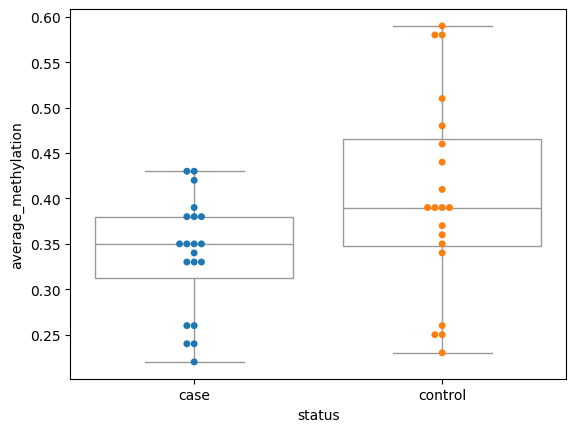

,LocusID,allele_length,chrom,start,end,is_ref,AC,AF,status
2400,562452,95,chr16,275573,275677,False,17,0.85,case
2401,562452,105,chr16,275573,275677,False,3,0.15,case
2441,562452,105,chr16,275573,275677,False,12,0.60,control
2442,562452,95,chr16,275573,275677,False,8,0.40,control


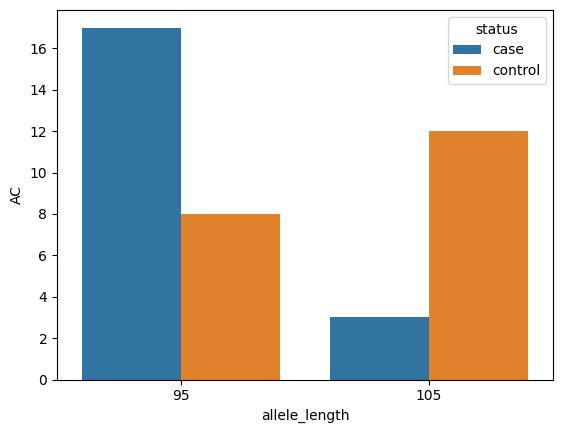

In [23]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

lid = 562452
view = methyl[methyl['LocusID'] == lid].reset_index()
p = sb.boxplot(data=view.reset_index(), 
            y="average_methylation", x="status", color='white')#, binwidth=0.03)
p = sb.swarmplot(data=view.reset_index(), 
            y="average_methylation", x="status", hue="status")#, binwidth=0.03)

plt.show()

a = case_af[case_af['LocusID'] == lid].copy()
a['status'] = 'case'
b = control_af[control_af['LocusID'] == lid].copy()
b['status'] = 'control'
view = pd.concat([a, b])
sb.barplot(data=view, x="allele_length", y="AC", hue="status")
view

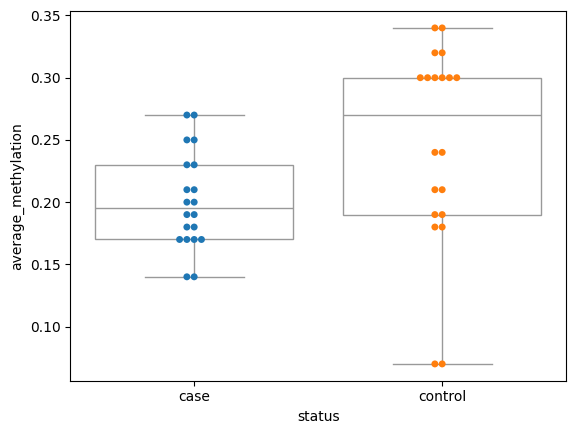

,LocusID,allele_length,chrom,start,end,is_ref,AC,AF,status
8108,1753437,81,chrX,100409683,100409764,True,20,1.0,case
8422,1753437,81,chrX,100409683,100409764,True,14,0.7,control
8423,1753437,90,chrX,100409683,100409764,False,6,0.3,control


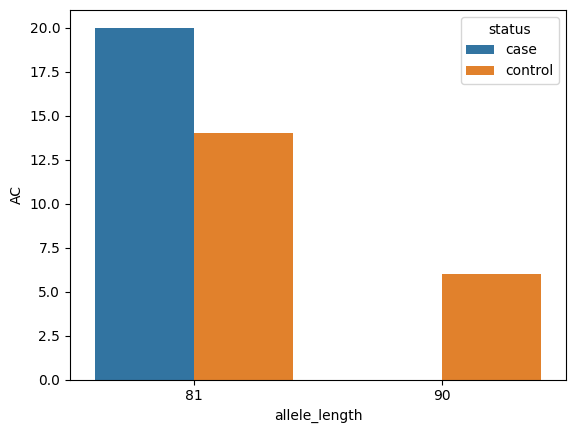

In [24]:
lid = 1753437
view = methyl[methyl['LocusID'] == lid].reset_index()
p = sb.boxplot(data=view.reset_index(), 
            y="average_methylation", x="status", color='white')#, binwidth=0.03)
p = sb.swarmplot(data=view.reset_index(), 
            y="average_methylation", x="status", hue="status")#, binwidth=0.03)
plt.show()

a = case_af[case_af['LocusID'] == lid].copy()
a['status'] = 'case'
b = control_af[control_af['LocusID'] == lid].copy()
b['status'] = 'control'
view = pd.concat([a, b])
sb.barplot(data=view, x="allele_length", y="AC", hue="status")
view